# Multi-source market data pipeline & data quality lab

Pull the same universe from several vendors, cache it, put every vendor on the same price basis, reconcile them, run assertion-based quality checks, and emit a report.

**Runs with zero setup** in *synthetic* mode (three fake vendors with recorded, injected defects). Add `FMP_API_KEY` / `POLYGON_API_KEY` to Colab Secrets (🔑 panel on the left) to run live; Yahoo needs no key.

Each section header below is one stage of the pipeline. The code lives in the `mdlab` package (tested, importable) — the notebook only *drives* it, so nothing here can drift from what the tests cover.

## 0 · Setup — install and import

In [1]:
# --- install --------------------------------------------------------------
import importlib, subprocess, sys, os, pathlib

REPO_URL = "https://github.com/<your-github-user>/market-data-lab.git"   # <- edit after you push

if pathlib.Path.cwd().name == "notebooks":       # opened from inside the repo
    os.chdir("..")

if importlib.util.find_spec("mdlab") is None:
    if pathlib.Path("market-data-lab").exists():
        os.chdir("market-data-lab")
    elif pathlib.Path("mdlab").exists():
        pass                                     # running inside the repo already
    else:
        subprocess.run(["git", "clone", "-q", REPO_URL], check=True)
        os.chdir("market-data-lab")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", "."], check=True)

import logging, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

import mdlab
from mdlab.config import Settings, configure_logging
configure_logging(logging.INFO)
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)
print("mdlab", mdlab.__version__, "| pandas", pd.__version__, "| cwd", os.getcwd())

mdlab 0.1.0 | pandas 3.0.2 | cwd /home/claude/market-data-lab


## 1 · Configuration and secrets

`Settings` resolves keys from **environment → Colab `userdata` → `.env`**, never from code. Vendors without a key are skipped with a warning rather than failing the run.

In [2]:
settings = Settings.from_env(cache_dir="cache", report_dir="reports")
print("live vendors available:", settings.available_vendors())
print({k: v for k, v in vars(settings).items() if "key" not in k})

# choose the run mode for the rest of the notebook
MODE = "synthetic"          # "synthetic" (no network) or "live" (Yahoo + any keyed vendors)
START, END = "2023-01-01", "2024-12-31"

live vendors available: ['yahoo']
{'cache_dir': PosixPath('cache'), 'report_dir': PosixPath('reports'), 'edgar_user_agent': 'market-data-lab contact@example.com', 'price_jump_threshold': 0.2, 'vendor_disagreement_threshold': 0.01, 'stale_run_length': 3, 'stale_series_bdays': 5, 'request_timeout': 30.0}


## 2 · Universe

~60 liquid large caps (boring on purpose), plus names with recent large splits (the acid test for adjustment logic) and three **probes** that *should* fail: `FB` (renamed to META, symbol later recycled to an ETF), `TWTR` and `ATVI` (acquired). A universe built from today's constituents never contains the last two — that is survivorship bias made concrete.

In [3]:
from mdlab.universe import default_universe, REFERENCE_SPLITS, KNOWN_TICKER_CHANGES, PROBES
TICKERS = default_universe()
print(len(TICKERS), "tickers:", TICKERS)
print("\nreference splits in window:")
for t, ev in REFERENCE_SPLITS.items():
    for d, r in ev:
        if START <= d <= END: print(f"  {t:5s} {d} {r:g}:1")
print("\nknown ticker changes:", KNOWN_TICKER_CHANGES)

73 tickers: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'AVGO', 'ORCL', 'CRM', 'ADBE', 'CSCO', 'INTC', 'AMD', 'QCOM', 'TXN', 'NFLX', 'DIS', 'CMCSA', 'TMUS', 'VZ', 'JPM', 'BAC', 'WFC', 'GS', 'MS', 'BLK', 'V', 'MA', 'AXP', 'BRK-B', 'JNJ', 'UNH', 'PFE', 'MRK', 'ABBV', 'LLY', 'TMO', 'ABT', 'AMGN', 'PG', 'KO', 'PEP', 'WMT', 'COST', 'HD', 'MCD', 'NKE', 'SBUX', 'TGT', 'CAT', 'HON', 'UNP', 'BA', 'GE', 'XOM', 'CVX', 'COP', 'LIN', 'NEE', 'DUK', 'AMT', 'PLD', 'TSLA', 'UBER', 'PLTR', 'F', 'GM', 'CMG', 'SMCI', 'LRCX', 'FB', 'TWTR', 'ATVI']

reference splits in window:
  NVDA  2024-06-10 10:1
  AVGO  2024-07-15 10:1
  WMT   2024-02-26 3:1
  CMG   2024-06-26 50:1
  SMCI  2024-10-01 10:1
  LRCX  2024-10-03 10:1

known ticker changes: {'FB': {'new_ticker': 'META', 'effective': '2022-06-09', 'reason': 'rename (Meta Platforms)'}, 'TWTR': {'new_ticker': None, 'effective': '2022-10-28', 'reason': 'taken private (X Corp)'}, 'ATVI': {'new_ticker': None, 'effective': '2023-10-13', 'reason': 'acquired by

## 3 · Data sources — one contract, one subclass per vendor

Every vendor implements `_fetch_ohlcv(ticker, start, end)`; the base class owns rate limiting, retry/backoff, caching, schema normalisation and pandera validation. Each vendor also **declares its conventions** — this is the part people get wrong:

| | `close_basis` | `adj_close_basis` | `actions_basis` |
|---|---|---|---|
| Yahoo | split_adjusted (!) | total_return | split_adjusted (!) |
| FMP | raw | total_return | raw |
| Polygon | raw | **split only** | raw |

In [4]:
from mdlab.cache import ParquetCache
from mdlab.sources import make_synthetic_trio, make_sources, YahooSource

cache = ParquetCache(settings.cache_dir)
if MODE == "synthetic":
    sources = make_synthetic_trio(cache=cache)
else:
    sources = make_sources(settings, cache=cache)

pd.DataFrame([{"vendor": s.name, "close_basis": s.close_basis, "adj_close_basis": s.adj_close_basis,
               "actions_basis": s.actions_basis, "rate_limit": s.rate_limit} for s in sources])

,vendor,close_basis,adj_close_basis,actions_basis,rate_limit
0,synth_a,split_adjusted,total_return,split_adjusted,None
1,synth_b,raw,total_return,raw,None
2,synth_c,raw,split,raw,None


In [5]:
# one call, canonical shape, regardless of vendor
bars = sources[0].get_ohlcv("NVDA", "2024-06-03", "2024-06-14")
bars

,open,high,low,close,adj_close,volume,dividends,splits
date,,,,,,,,
2024-06-03,337.774622,340.491340,334.219383,335.819130,335.819130,12781590.0,0.0,0.0
2024-06-04,336.194916,344.218367,335.314785,342.598661,342.598661,15567820.0,0.0,0.0
2024-06-05,341.865990,344.465723,340.417957,343.377092,343.377092,17300580.0,0.0,0.0
2024-06-06,343.539845,343.815691,338.607005,339.743403,339.743403,13613140.0,0.0,0.0
2024-06-07,343.539845,343.815691,338.607005,339.743403,339.743403,9113620.0,0.0,0.0
2024-06-10,343.539845,343.815691,338.607005,339.743403,339.743403,13337123.0,0.0,10.0
2024-06-11,343.539845,343.815691,338.607005,339.743403,339.743403,11194251.0,0.0,0.0
2024-06-12,342.118851,348.694236,338.119461,345.125110,345.125110,11295612.0,0.0,0.0
2024-06-13,347.346705,360.086128,345.394841,358.689722,358.689722,20393694.0,0.0,0.0


In [6]:
# Yahoo's "unadjusted" Close is split-adjusted — see for yourself (needs network)
try:
    y = YahooSource(cache=cache)
    yb = y.get_ohlcv("NVDA", "2024-06-05", "2024-06-11")
    display(yb[["close", "adj_close", "volume", "splits", "dividends"]])
    print("NVDA actually closed at $1,208.88 on 2024-06-07; Yahoo says", round(yb.loc["2024-06-07", "close"], 3))
except Exception as e:
    print("Yahoo not reachable:", e)

,close,adj_close,volume,splits,dividends
date,,,,,
2024-06-05,122.440002,122.091873,528402000.0,0.0,0.00
2024-06-06,120.998001,120.653961,664696000.0,0.0,0.00
2024-06-07,120.888000,120.544281,412386000.0,0.0,0.00
2024-06-10,121.790001,121.443703,313434100.0,10.0,0.00
2024-06-11,120.910004,120.576134,222551200.0,0.0,0.01


NVDA actually closed at $1,208.88 on 2024-06-07; Yahoo says 120.888


## 4 · Parquet cache and retry/backoff

Cache key = `(source, ticker, start, end)`. The window is part of the key because vendors restate history. Second call: 0 requests.

In [7]:
src = sources[0]
cache.stats.__init__()                       # reset counters
t0 = time.perf_counter(); src.get_ohlcv("AAPL", START, END, use_cache=True); t1 = time.perf_counter()
src.get_ohlcv("AAPL", START, END); t2 = time.perf_counter()
print(f"cold {t1-t0:.3f}s  warm {t2-t1:.4f}s  |", cache.stats.as_dict())
print(cache.path_for(src.name, "AAPL", START, END))
cache.inventory().head()

cold 0.062s  warm 0.3234s  | {'hits': 1, 'misses': 1, 'writes': 1, 'hit_rate': 0.5, 'mb_written': 0.033}
cache/synth_a/AAPL/2023-01-01_2024-12-31.parquet


,source,ticker,start,end,rows,written_at
0,yahoo,NVDA,2024-06-05,2024-06-11,5,2026-09-25T18:22:43.094237+00:00
1,synth_a,NVDA,2024-06-03,2024-06-14,10,2026-09-25T18:22:41.608543+00:00
2,synth_a,AAPL,2023-01-01,2024-12-31,497,2026-09-25T18:22:43.171759+00:00


In [8]:
# retry semantics: transient errors are retried with exponential backoff, permanent ones are not
from mdlab.sources.base import DataSource, TransientError, PermanentError, NoDataError
import mdlab.sources.base as base

class Flaky(DataSource):
    name = "flaky"
    def __init__(self, fail_times): super().__init__(); self.fail_times, self.calls = fail_times, 0
    def _fetch_ohlcv(self, ticker, start, end):
        self.calls += 1
        if self.calls <= self.fail_times: raise TransientError(f"HTTP 503 (attempt {self.calls})")
        return pd.DataFrame({"open":[1,1],"high":[2,2],"low":[.5,.5],"close":[1.0,1.1],"volume":[1,1]},
                            index=pd.to_datetime(["2024-01-02","2024-01-03"]))

base.DataSource._fetch_with_retry.retry.wait = lambda *a, **k: 0.05   # keep the demo fast
f = Flaky(fail_times=2); out = f.get_ohlcv("T", "2024-01-01", "2024-01-31")
print("calls made:", f.calls, "| rows:", len(out), "| stats:", f.stats.as_dict())

18:22:43 | WARNING | mdlab.sources.base | retry 1/5 after 0.1s — TransientError: HTTP 503 (attempt 1)


18:22:43 | WARNING | mdlab.sources.base | retry 2/5 after 0.1s — TransientError: HTTP 503 (attempt 2)


calls made: 3 | rows: 2 | stats: {'requests': 3, 'cache_hits': 0, 'errors': 0, 'no_data': 0, 'seconds': 0.13, 'rate_limit_sleep_s': 0.0}


## 5 · Build the panel

`fetch_panel` iterates vendors × tickers with per-item error isolation, stacks a long `(source, ticker, date)` frame, and picks **one reference corporate-action table per ticker** (dividends normalised to raw share terms). `add_rebased_closes` attaches `close_split`, `close_tr`, `volume_split` computed by *our* engine.

In [9]:
from mdlab.panel import fetch_panel, add_rebased_closes
panel = fetch_panel(sources, TICKERS, START, END, progress=print)
panel = add_rebased_closes(panel)
print(panel.long.shape, "| sources:", panel.sources)
display(panel.failures)
panel.coverage().head(12)

10/219 fetched  (synth_a:ADBE)    0.5s


20/219 fetched  (synth_a:VZ)    1.1s


30/219 fetched  (synth_a:BRK-B)    1.7s


40/219 fetched  (synth_a:PG)    2.2s


50/219 fetched  (synth_a:CAT)    2.8s


...

210/219 fetched  (synth_c:UBER)    8.6s


18:22:53 | INFO    | mdlab.panel | panel: 103977 rows, 3 sources, 70 tickers, 11 failures, 9.8s


(103977, 14) | sources: {'synth_a': {'close_basis': 'split_adjusted', 'adj_close_basis': 'total_return'}, 'synth_b': {'close_basis': 'raw', 'adj_close_basis': 'total_return'}, 'synth_c': {'close_basis': 'raw', 'adj_close_basis': 'split'}}


,source,ticker,error
0,synth_a,PLD,NoData: empty response
1,synth_a,FB,NoData: empty response
2,synth_a,TWTR,NoData: empty response
3,synth_a,ATVI,NoData: empty response
4,synth_b,PEP,SchemaErrors: pandera rejected payload: close ...
5,synth_b,FB,NoData: empty response
6,synth_b,TWTR,NoData: empty response
7,synth_b,ATVI,NoData: empty response
8,synth_c,FB,NoData: empty response
9,synth_c,TWTR,NoData: empty response


,source,ticker,rows,first,last
0,synth_a,AAPL,497,2023-01-03,2024-12-31
1,synth_a,ABBV,497,2023-01-03,2024-12-31
2,synth_a,ABT,497,2023-01-03,2024-12-31
3,synth_a,ADBE,497,2023-01-03,2024-12-31
4,synth_a,AMD,497,2023-01-03,2024-12-31
5,synth_a,AMGN,497,2023-01-03,2024-12-31
6,synth_a,AMT,497,2023-01-03,2024-12-31
7,synth_a,AMZN,497,2023-01-03,2024-12-31
8,synth_a,AVGO,497,2023-01-03,2024-12-31
9,synth_a,AXP,497,2023-01-03,2024-12-31


In [10]:
wide = panel.wide("close_tr")        # date × (source, ticker)
wide.iloc[-3:, :6]

source         synth_a                                                          
ticker            AAPL        ABBV         ABT        ADBE        AMD       AMGN
date                                                                            
2024-12-27  466.237648  107.701040  165.915750  389.125601  68.211245  84.142495
2024-12-30  452.698076  104.781524  165.072179  386.929444  67.492664  84.326169
2024-12-31  455.578179  106.114134  171.109303  389.923824  67.224919  81.995479

## 6 · Corporate-action adjustment

A split multiplies pre-split prices by `1/r` (and volume by `r`); a dividend multiplies pre-ex-date prices by `1 − D / P_{t−1}` (CRSP). Factors compound **backwards** from the latest bar.

,raw,split,total_return
date,,,
2024-06-05,5438.149,543.815,538.390
2024-06-06,5373.973,537.397,532.037
2024-06-07,5415.323,541.532,536.131
2024-06-10,557.502,557.502,551.941
2024-06-11,548.002,548.002,542.536
2024-06-12,567.675,567.675,562.012


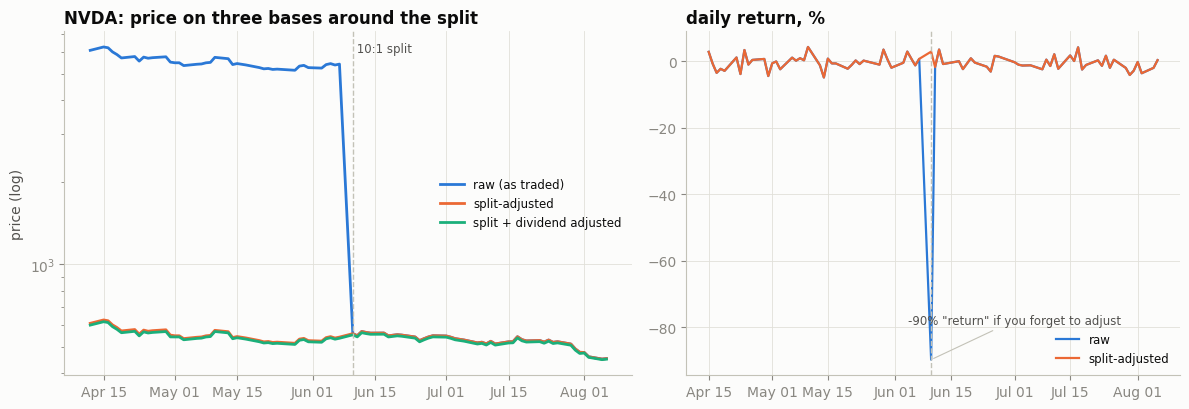

In [11]:
from mdlab.adjust import compare_bases, adjust_bars
from mdlab import viz

tkr = "NVDA"
src_name = next(s for s in panel.source_names if panel.sources[s]["close_basis"] == "raw")
b = panel.bars(src_name, tkr); div, spl = panel.actions[tkr]
bases = compare_bases(b, spl, div, input_basis=panel.sources[src_name]["close_basis"])
display(bases.loc["2024-06-05":"2024-06-12"].round(3))
fig = viz.plot_adjustment_overlay(bases, tkr, spl.index[-1], float(spl.iloc[-1])); plt.show()

## 7 · Reconciliation — do the vendors agree?

Two comparisons on purpose. **Fair**: our re-based `close_split` for every vendor (residual = data error). **Unfair**: each vendor's own `adj_close` (residual = methodology — split-only vs total-return). The `methodology_gap` staircase is the fingerprint of a vendor that ignores dividends.

,pair,n_days,n_both,coverage_gap_pct,median_abs_bps,p99_abs_bps,max_abs_pct,pct_beyond_tol,mean_signed_bps
0,synth_a|synth_b,34136.0,33796.0,1.00,0.0,300.36,200.37,1.24,169.09
1,synth_a|synth_c,34637.0,34201.0,1.26,0.0,284.72,200.37,1.22,167.28
2,synth_b|synth_c,34638.0,34545.0,0.27,0.0,0.00,50.00,0.01,0.29


,date,ticker,pair,diff_pct
0,2023-12-12,WMT,synth_a|synth_b,200.373386
1,2023-12-12,WMT,synth_a|synth_c,200.373386
2,2023-04-10,WMT,synth_a|synth_b,200.000000
3,2023-04-13,WMT,synth_a|synth_b,200.000000
4,2023-11-08,WMT,synth_a|synth_b,200.000000
5,2023-12-27,WMT,synth_a|synth_b,200.000000
6,2024-01-11,WMT,synth_a|synth_b,200.000000
7,2024-01-16,WMT,synth_a|synth_b,200.000000
8,2024-01-19,WMT,synth_a|synth_b,200.000000
9,2024-02-14,WMT,synth_a|synth_b,200.000000


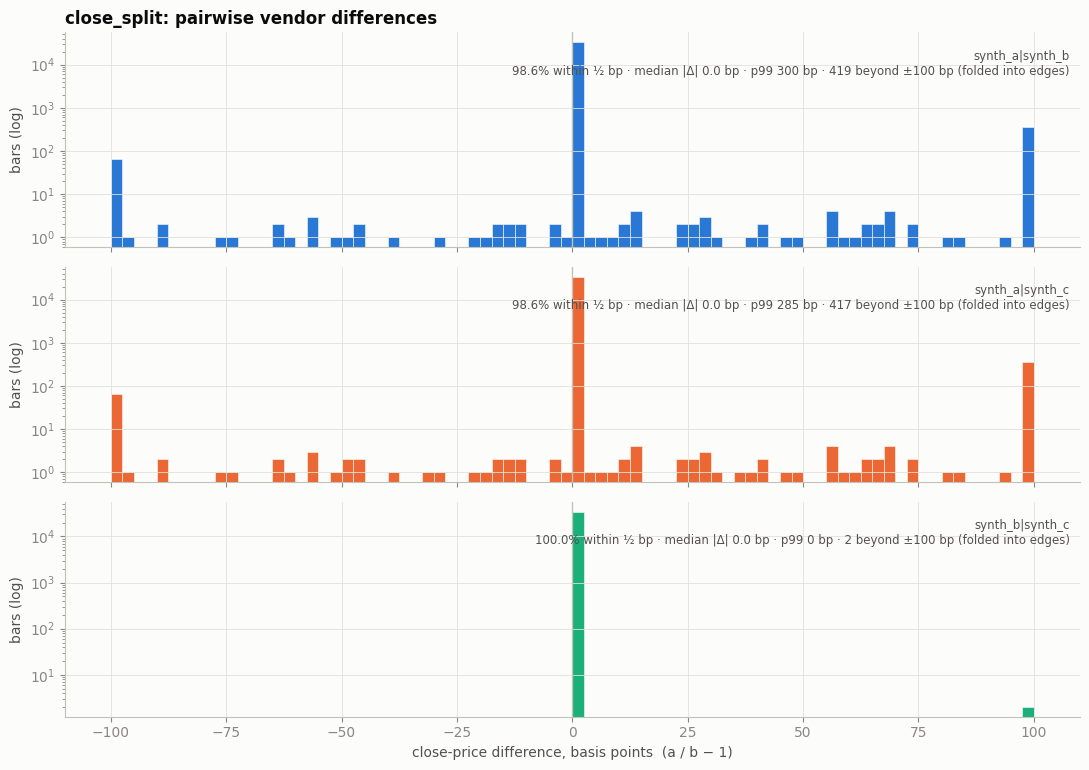

In [12]:
from mdlab.reconcile import reconcile, methodology_gap
rec = reconcile(panel, "close_split", settings.vendor_disagreement_threshold)
rec_adj = reconcile(panel, "adj_close", settings.vendor_disagreement_threshold)
display(rec.pair_summary.round(2)); display(rec.worst(10))
fig = viz.plot_vendor_diff_distribution(rec.pair_diffs, "close_split: pairwise vendor differences"); plt.show()

,,median_gap_bps,gap_at_start_bps,pct_days_beyond_tol
source,vendor_adj_basis,,,
synth_a,total_return,0.0,0.0,0.0
synth_b,total_return,0.0,0.0,0.0
synth_c,split,202.5,357.1,78.8


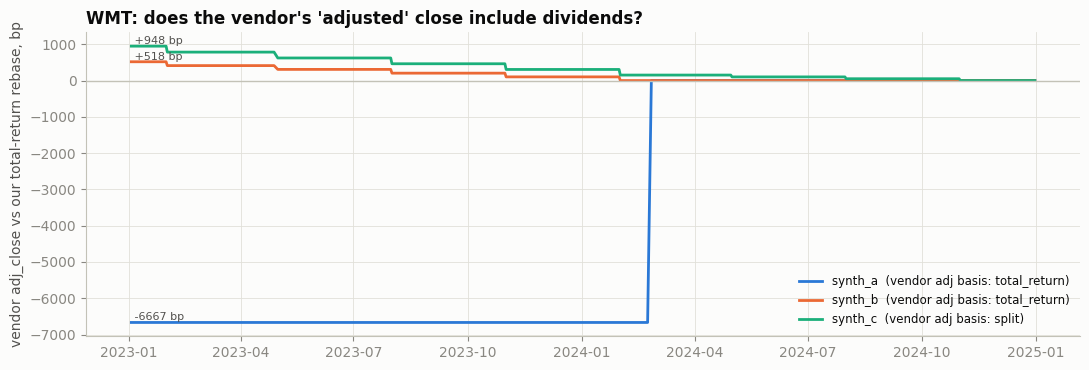

In [13]:
mg = methodology_gap(panel)
display(mg.groupby(["source", "vendor_adj_basis"])[["median_gap_bps", "gap_at_start_bps", "pct_days_beyond_tol"]].median().round(1))
pal = viz.VendorPalette(panel.source_names)
gap_tkr = mg[mg["vendor_adj_basis"] == "split"].sort_values("median_gap_bps").iloc[-1]["ticker"] if (mg["vendor_adj_basis"] == "split").any() else mg.iloc[0]["ticker"]
fig = viz.plot_methodology_gap(panel.long, gap_tkr, pal, panel.sources); plt.show()

## 8 · Quality checks — functions returning boolean Series (`True` = FAIL)

10 bar-level + 6 ticker-level checks, registered by decorator. Adding one is one function.

bar checks: ['missing_bar', 'zero_volume', 'price_jump', 'split_adjustment_mismatch', 'stale_print', 'ohlc_integrity', 'non_positive_price', 'vendor_disagreement', 'volume_outlier', 'duplicate_bar']
ticker checks: ['stale_series', 'late_start', 'no_data', 'ingest_rejected', 'ticker_change', 'coverage_mismatch']


18:23:02 | INFO    | mdlab.quality | quality: {'bars_checked': 104392.0, 'bar_checks': 10.0, 'ticker_checks': 6.0, 'bars_with_any_failure': 1117.0, 'bar_failure_rate_pct': 1.07, 'ticker_level_failures': 24.0, 'clean_series': 206.0}


bars_checked             104392.00
bar_checks                   10.00
ticker_checks                 6.00
bars_with_any_failure      1117.00
bar_failure_rate_pct          1.07
ticker_level_failures        24.00
clean_series                206.00
dtype: float64

,check,source,failures,fail_rate_pct
0,vendor_disagreement,synth_a,417,1.203880
1,missing_bar,synth_a,345,0.996016
2,stale_print,synth_a,207,0.597610
3,zero_volume,synth_b,207,0.597610
4,missing_bar,synth_c,70,0.199339
5,price_jump,synth_b,4,0.011548
6,no_data,synth_a,4,NaN
7,ticker_change,synth_c,3,NaN
8,no_data,synth_c,3,NaN
9,no_data,synth_b,3,NaN


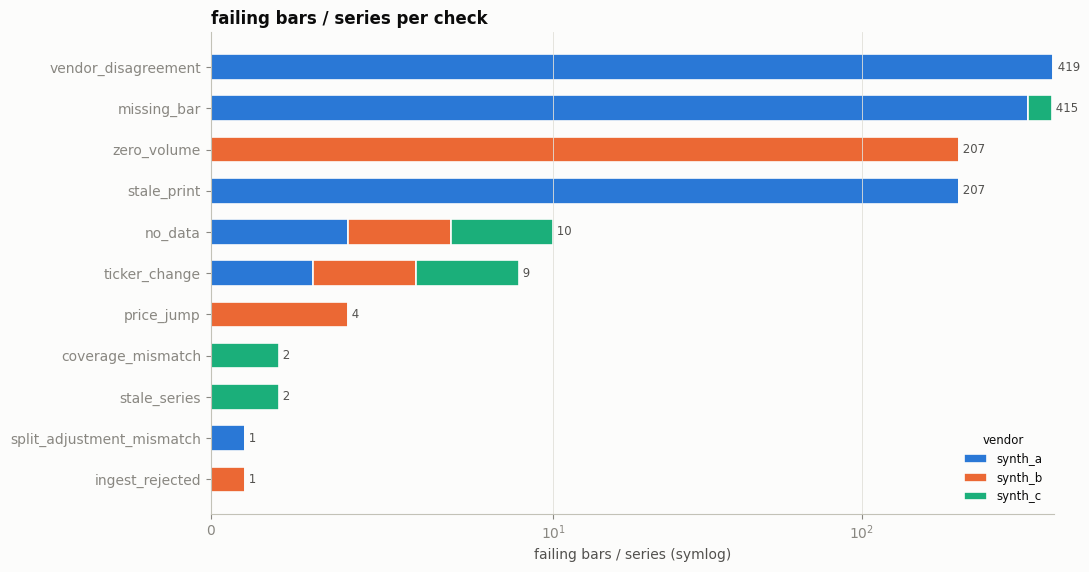

In [14]:
from mdlab.quality import run_checks, BAR_CHECKS, TICKER_CHECKS, score_against_injected
print("bar checks:", list(BAR_CHECKS)); print("ticker checks:", list(TICKER_CHECKS))
qr = run_checks(panel, settings)
display(qr.scorecard()); display(qr.summary_by_check())
fig = viz.plot_failures_by_check(qr.summary_by_check(), pal, "failing bars / series per check"); plt.show()

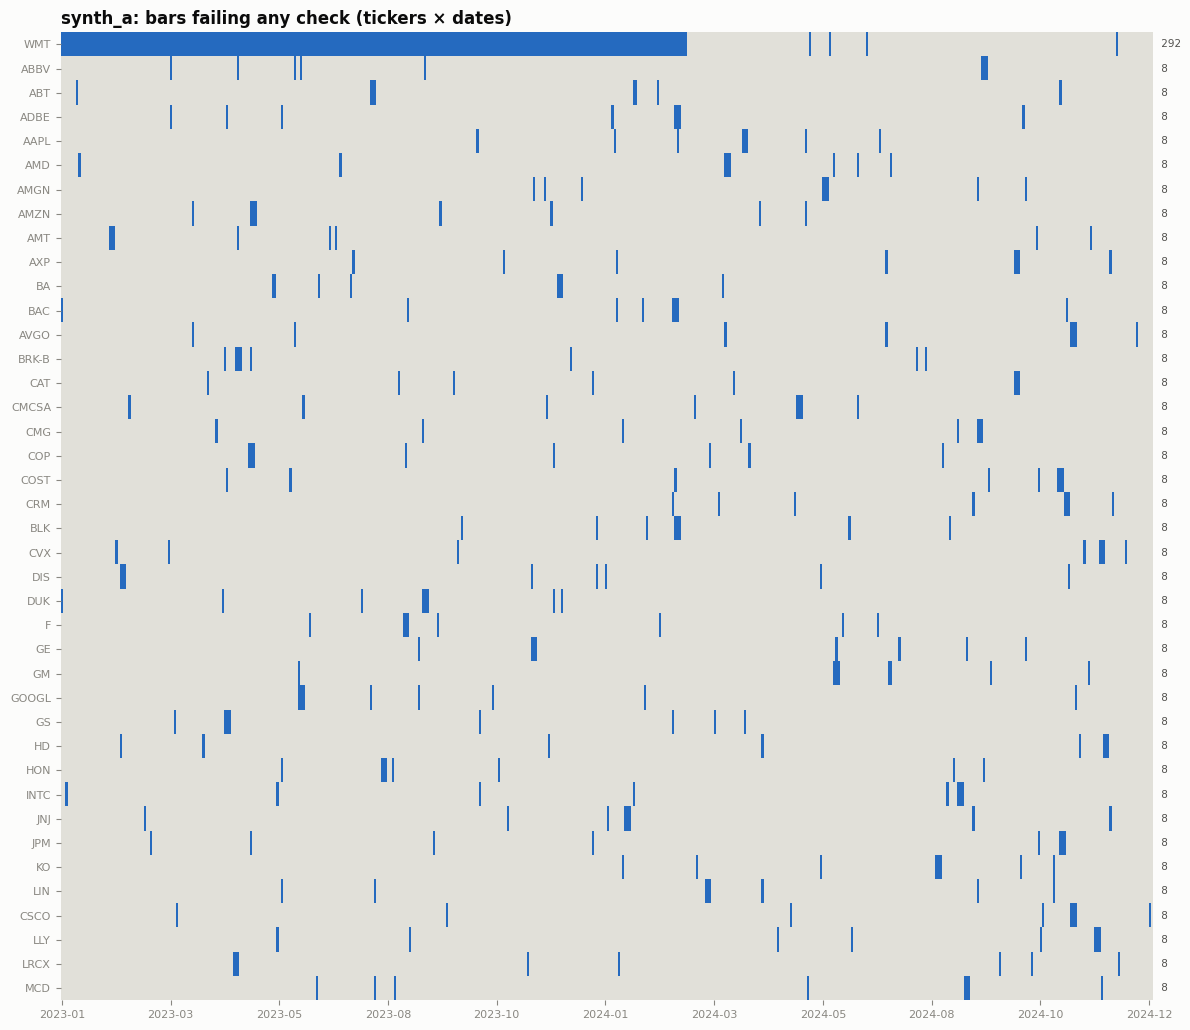

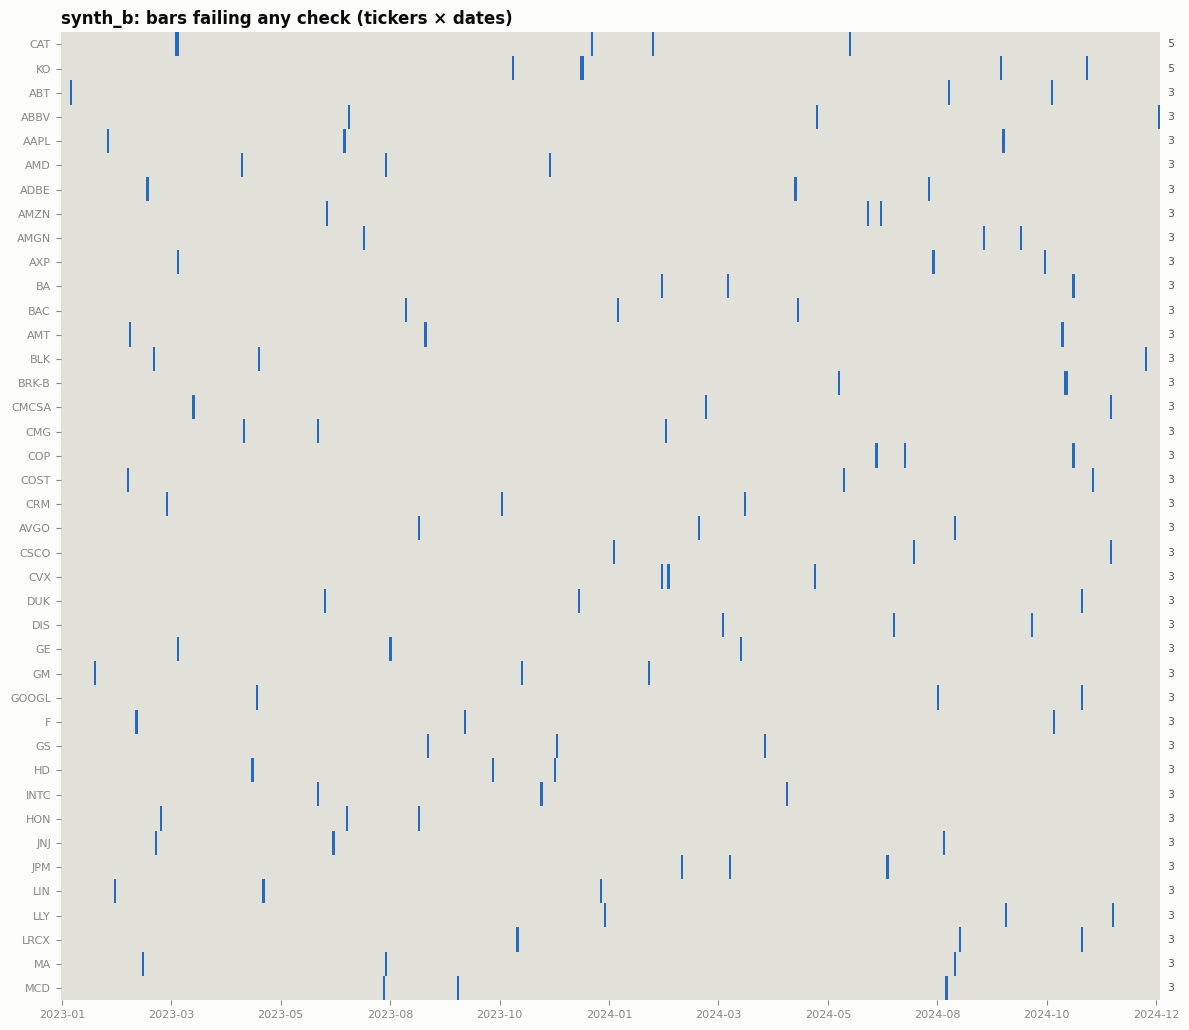

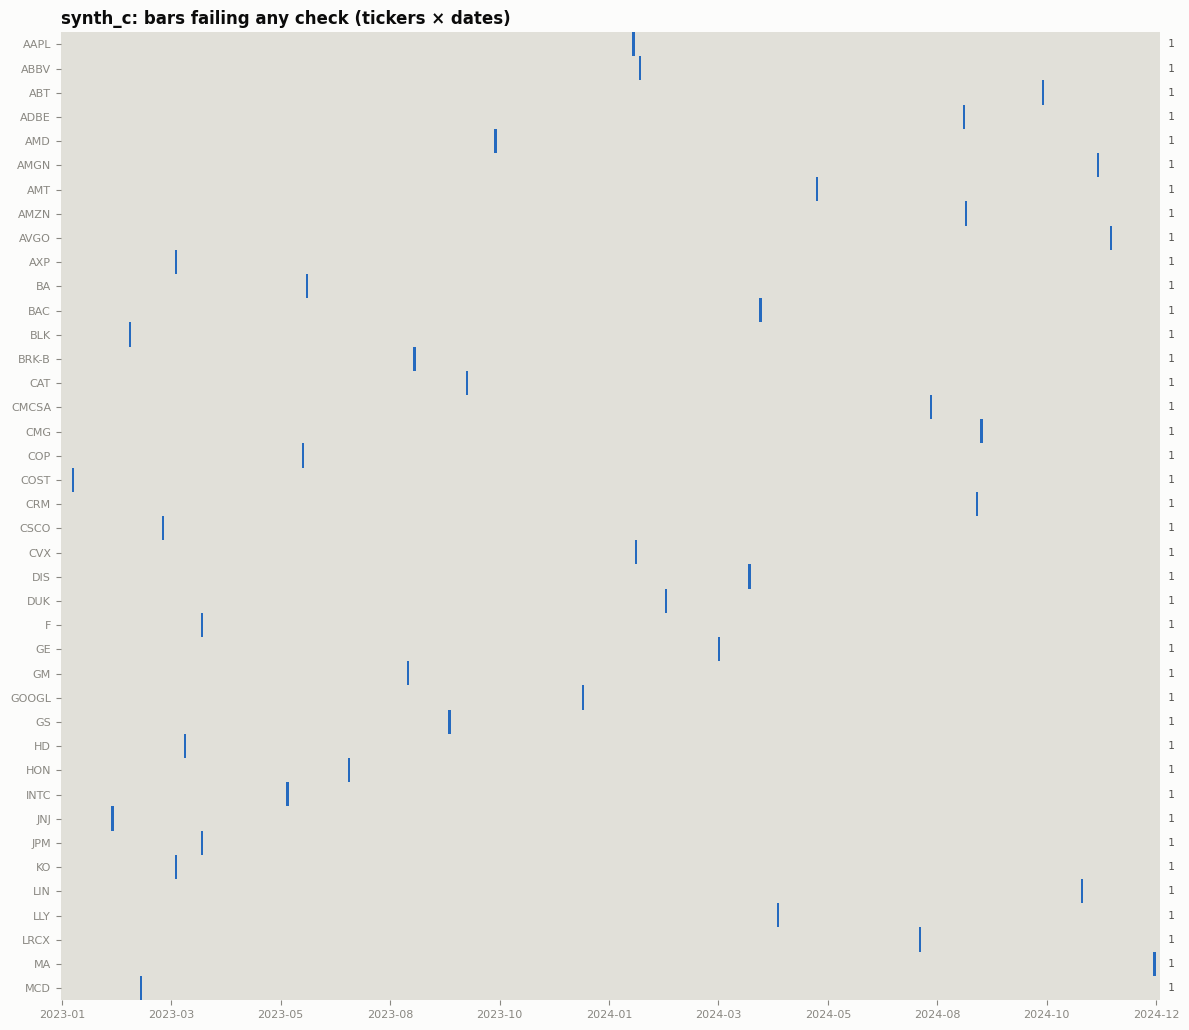

In [15]:
for s_ in panel.source_names:
    fig = viz.plot_failure_heatmap(qr.matrix(s_), f"{s_}: bars failing any check (tickers × dates)", max_tickers=40); plt.show()

In [16]:
# write your own check in three lines: it is picked up by run_checks automatically
from mdlab.quality import bar_check, _indexed
@bar_check
def huge_range(panel, settings):
    df = _indexed(panel)
    return ((df["high"] / df["low"] - 1) > 0.25).fillna(False).rename("huge_range")
qr2 = run_checks(panel, settings, checks=["huge_range", "price_jump"])
qr2.summary_by_check()

18:23:04 | INFO    | mdlab.quality | quality: {'bars_checked': 103977.0, 'bar_checks': 11.0, 'ticker_checks': 6.0, 'bars_with_any_failure': 22.0, 'bar_failure_rate_pct': 0.021, 'ticker_level_failures': 0.0, 'clean_series': 208.0}


,check,source,failures,fail_rate_pct
0,huge_range,synth_a,6,0.017496
1,huge_range,synth_b,6,0.017322
2,huge_range,synth_c,6,0.017120
3,price_jump,synth_b,4,0.011548


## 9 · Detection scorecard (synthetic mode)

Every defect the fake vendors injected was recorded, so the checks get a recall/precision instead of a vibe.

In [17]:
if MODE == "synthetic":
    injected = pd.concat([s.injected_frame() for s in sources], ignore_index=True)
    display(injected["kind"].value_counts())
    display(score_against_injected(qr, injected, expected_absent=tuple(PROBES)))
else:
    print("live mode: no ground truth — see the reconciliation tables instead")

kind
missing_bar               415
stale_print               210
zero_volume               210
price_spike                 2
truncated_series            2
mislabeled_split_basis      1
missing_ticker              1
ohlc_violation              1
Name: count, dtype: int64

,defect,check,injected,detected,recall,flagged_total,precision_vs_injected
0,missing_bar,missing_bar,415,415,1.000000,415,1.0
1,zero_volume,zero_volume,207,207,1.000000,207,1.0
2,stale_print,stale_print,210,207,0.985714,207,1.0
3,price_spike,price_jump,2,2,1.000000,2,1.0
4,truncated_series,stale_series,2,2,1.000000,2,1.0
5,mislabeled_split_basis,split_adjustment_mismatch,1,1,1.000000,1,1.0
6,ohlc_violation,ingest_rejected,1,1,1.000000,1,1.0
7,missing_ticker,no_data,1,1,1.000000,1,1.0


## 10 · Ticker changes via SEC EDGAR

A ticker is a label; the CIK is the entity. `FB` → `META` (2022-06-09), and the `FB` symbol was later reissued to an ETF. EDGAR's ticker→CIK map is fetched live (descriptive `User-Agent` required); the curated table is the offline fallback.

In [18]:
from mdlab.edgar import EdgarClient, ticker_change_report
client = EdgarClient(settings.edgar_user_agent, cache_dir=settings.cache_dir / "edgar") if MODE == "live" else None
edgar_df = ticker_change_report(TICKERS, client)
edgar_df[edgar_df["status"] != "listed"]

,ticker,status,new_ticker,effective,reason,edgar_live
0,AAPL,unknown_offline,NaN,NaN,NaN,False
1,MSFT,unknown_offline,NaN,NaN,NaN,False
2,GOOGL,unknown_offline,NaN,NaN,NaN,False
3,AMZN,unknown_offline,NaN,NaN,NaN,False
4,META,unknown_offline,NaN,NaN,NaN,False
...,...,...,...,...,...,...
68,SMCI,unknown_offline,NaN,NaN,NaN,False
69,LRCX,unknown_offline,NaN,NaN,NaN,False
70,FB,changed,META,2022-06-09,rename (Meta Platforms),False
71,TWTR,changed,NaN,2022-10-28,taken private (X Corp),False


## 11 · The report — one call, one HTML file

`run_pipeline` does everything above and writes `reports/data_quality_report.html` (figures embedded) + a Markdown twin.

In [19]:
from mdlab.pipeline import run_pipeline
notes = open("docs/discrepancies.md").read() if os.path.exists("docs/discrepancies.md") else None
res = run_pipeline(TICKERS, START, END, mode=MODE, settings=settings, use_edgar=(MODE == "live"),
                   discrepancy_notes=notes, progress=False)
display(res.summary())
print(res.report_paths)

18:23:04 | INFO    | mdlab.pipeline | mode=synthetic vendors=['synth_a', 'synth_b', 'synth_c'] tickers=73 window=2023-01-01..2024-12-31


18:23:04 | ERROR   | mdlab.schema | schema validation failed for synth_b:PEP: 16 failure cases


18:23:04 | ERROR   | mdlab.sources.base | synth_b: failed PEP (SchemaErrors: { "DATA": { "DATAFRAME_CHECK": [ { "schema": null, "column": null, "check": "high < low", "error": "DataFrameSchema 'None' failed element-wise validator number )


18:23:06 | INFO    | mdlab.panel | panel: 103977 rows, 3 sources, 70 tickers, 11 failures, 2.1s


18:23:13 | INFO    | mdlab.quality | quality: {'bars_checked': 104392.0, 'bar_checks': 11.0, 'ticker_checks': 6.0, 'bars_with_any_failure': 1134.0, 'bar_failure_rate_pct': 1.086, 'ticker_level_failures': 24.0, 'clean_series': 206.0}


18:23:23 | INFO    | mdlab.report | report written: reports/data_quality_report.html (1227.5 KB), reports/data_quality_report.md


18:23:23 | INFO    | mdlab.pipeline | pipeline done in 19.5s


bars_checked                              104392.0
bar_checks                                    11.0
ticker_checks                                  6.0
bars_with_any_failure                       1134.0
bar_failure_rate_pct                         1.086
ticker_level_failures                         24.0
clean_series                                 206.0
vendors                  synth_a, synth_b, synth_c
tickers                                         70
fetch_seconds                                  2.1
cache_hit_rate                              0.9954
dtype: object

{'html': PosixPath('reports/data_quality_report.html'), 'markdown': PosixPath('reports/data_quality_report.md')}


source,ticker,error
synth_a,PLD,NoData: empty response
synth_a,FB,NoData: empty response
synth_a,TWTR,NoData: empty response
synth_a,ATVI,NoData: empty response
synth_b,PEP,"SchemaErrors: pandera rejected payload: close outside [low, high], high < low"
synth_b,FB,NoData: empty response
synth_b,TWTR,NoData: empty response
synth_b,ATVI,NoData: empty response
synth_c,FB,NoData: empty response
synth_c,TWTR,NoData: empty response

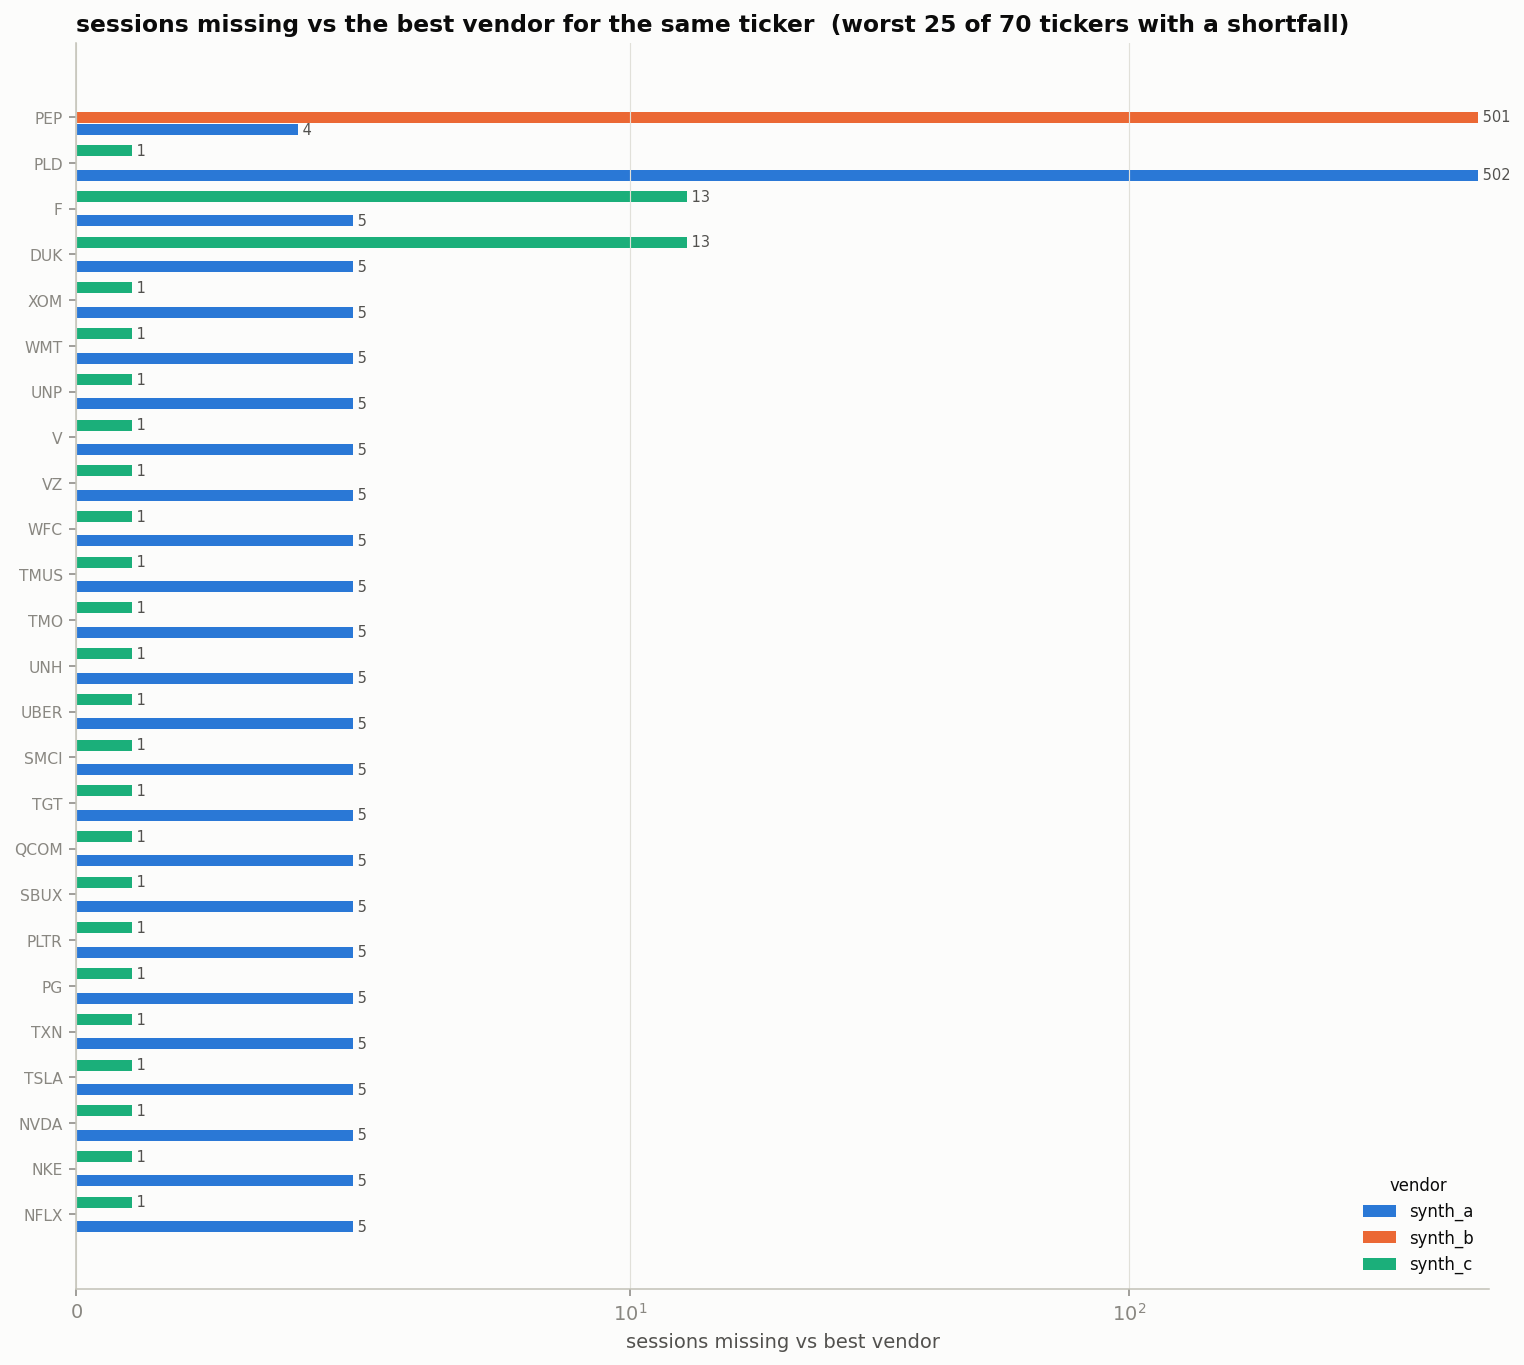
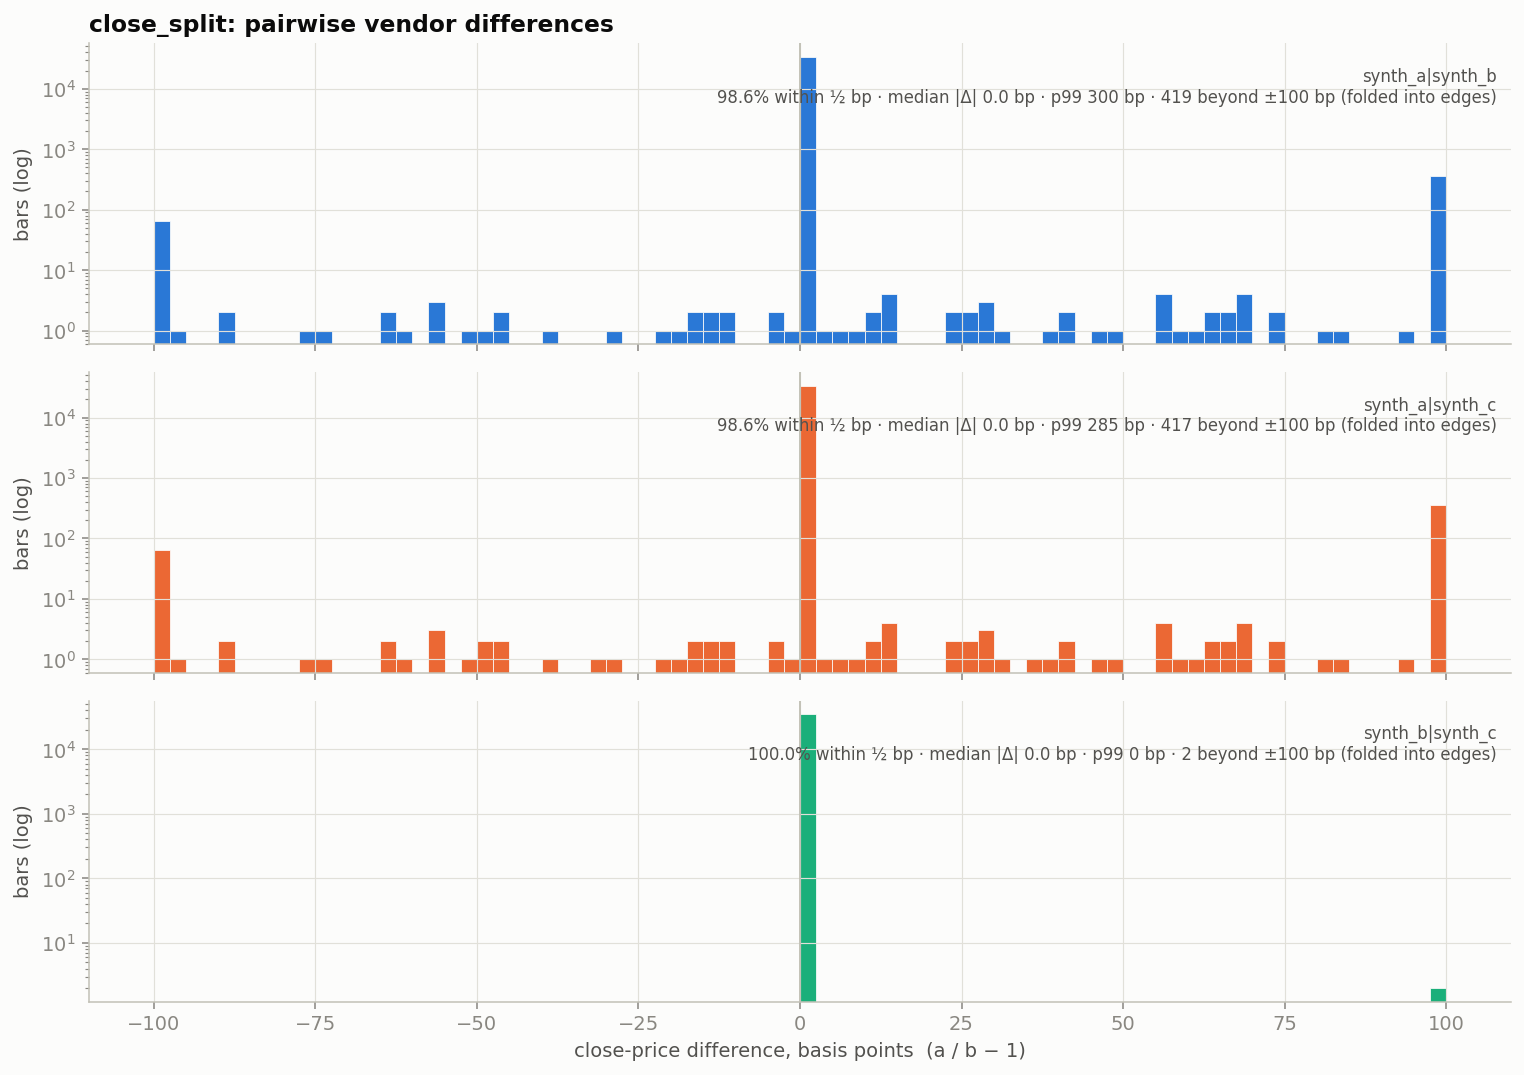
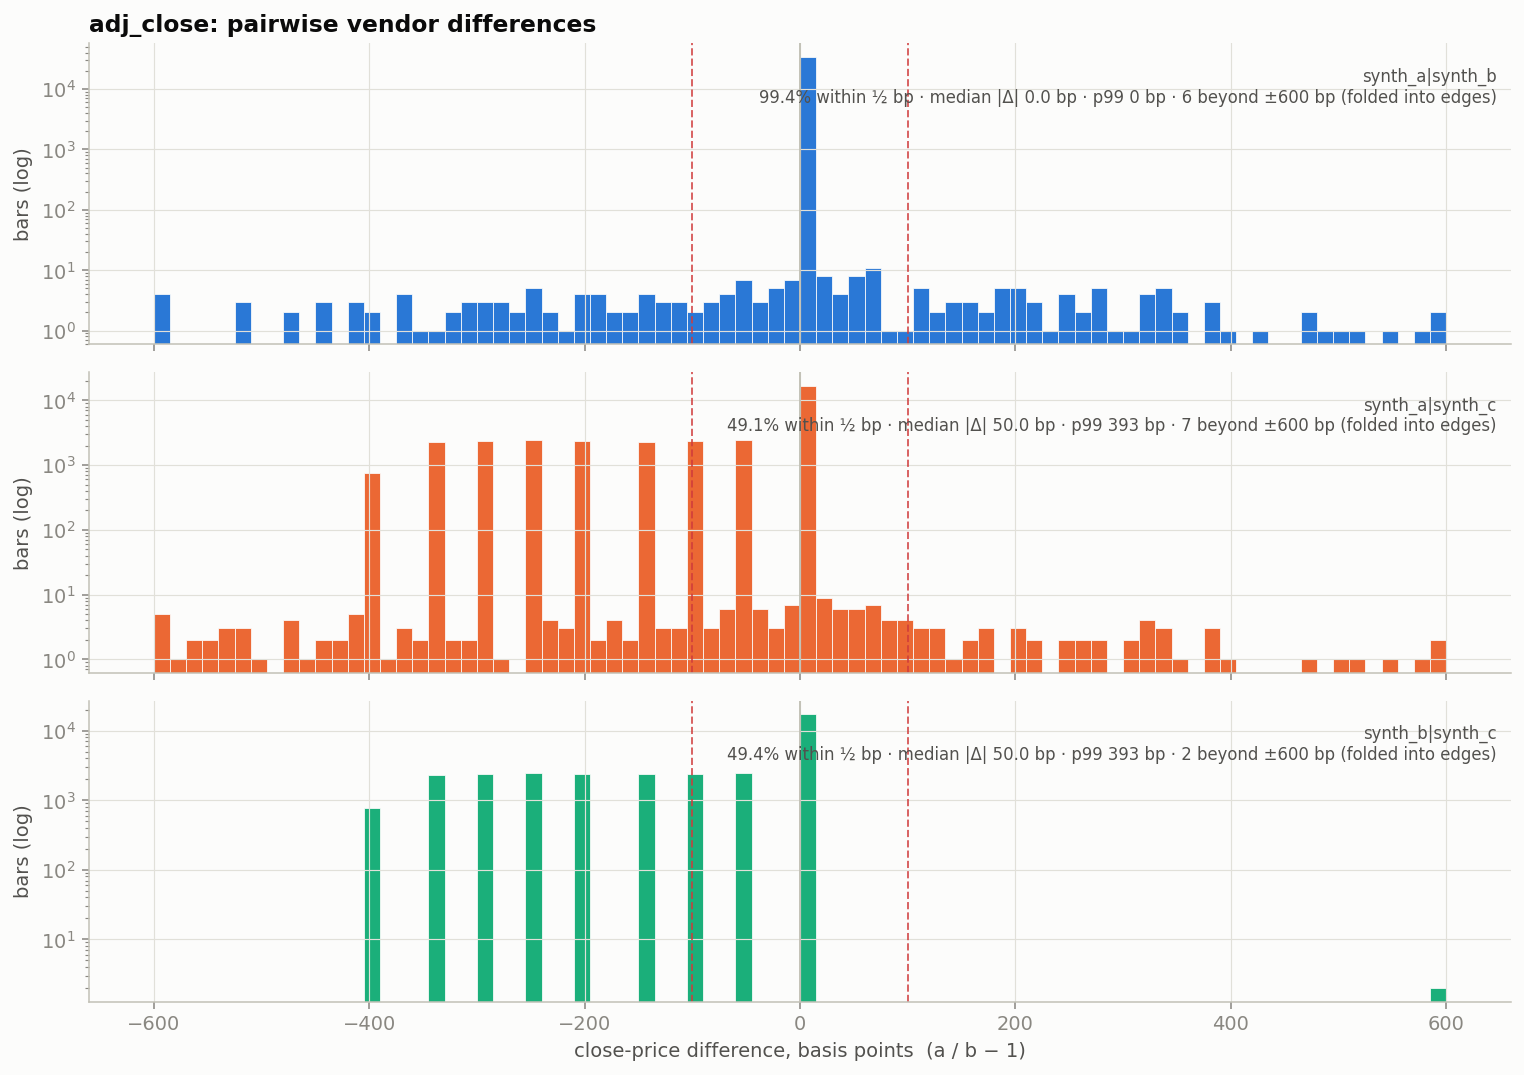
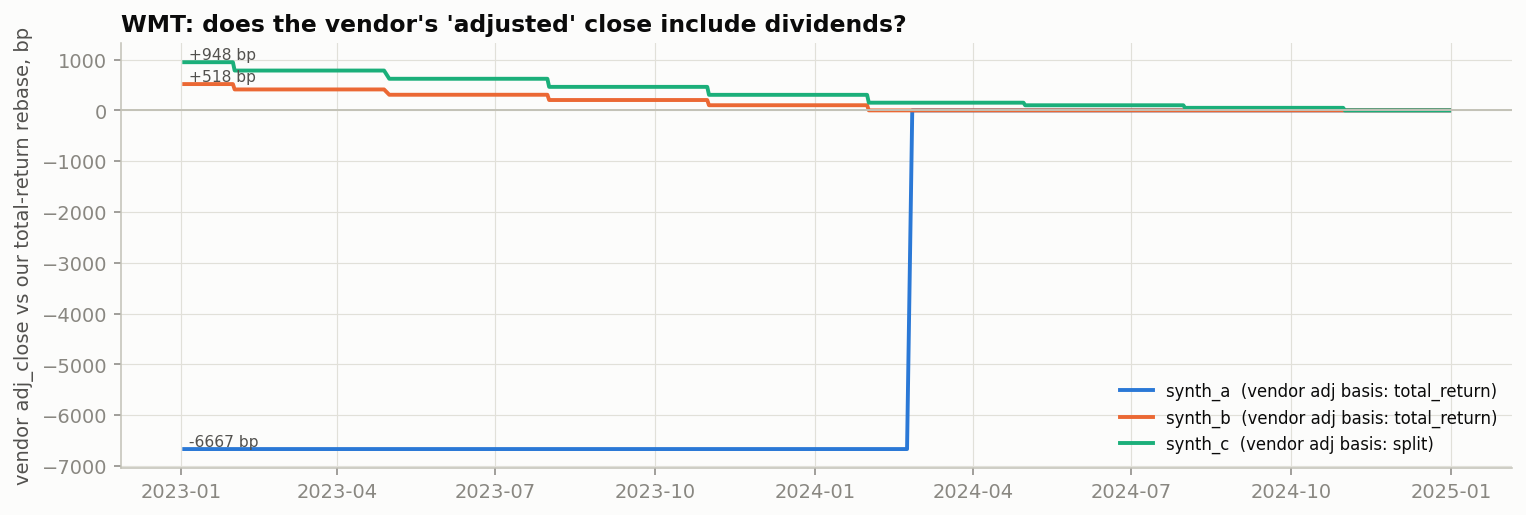
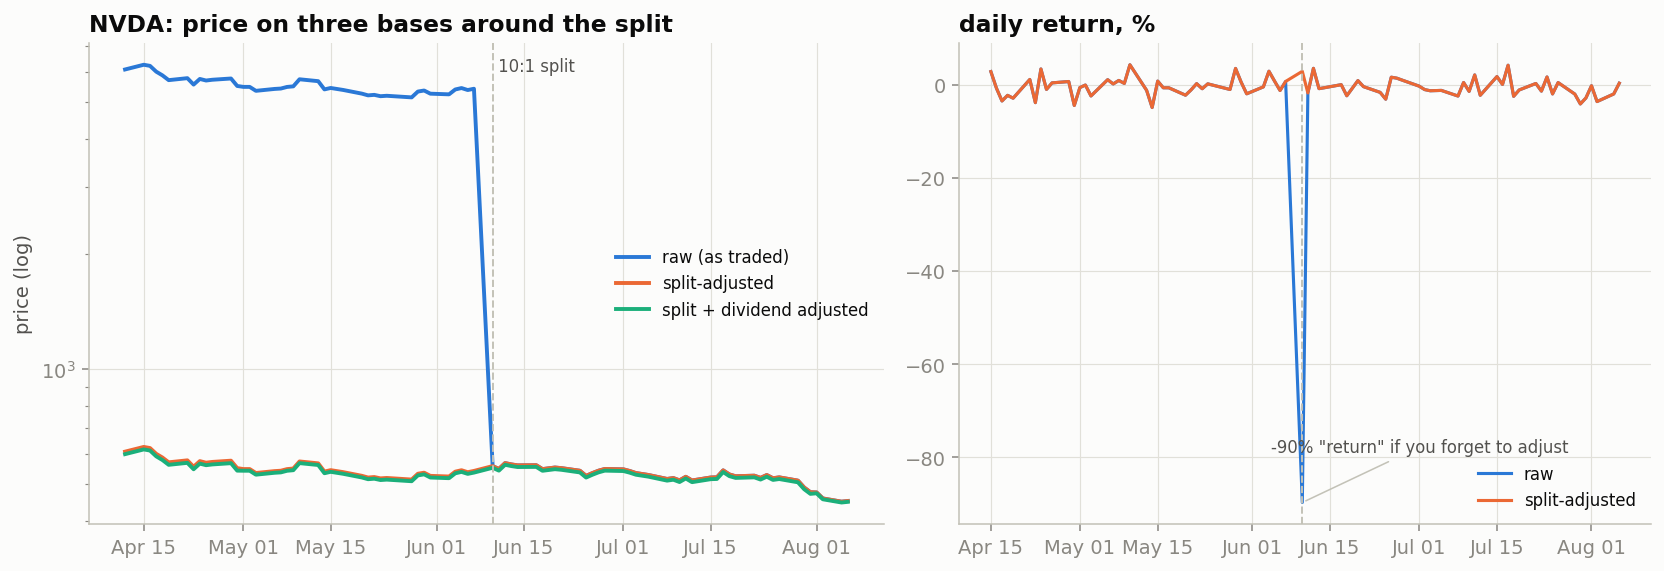
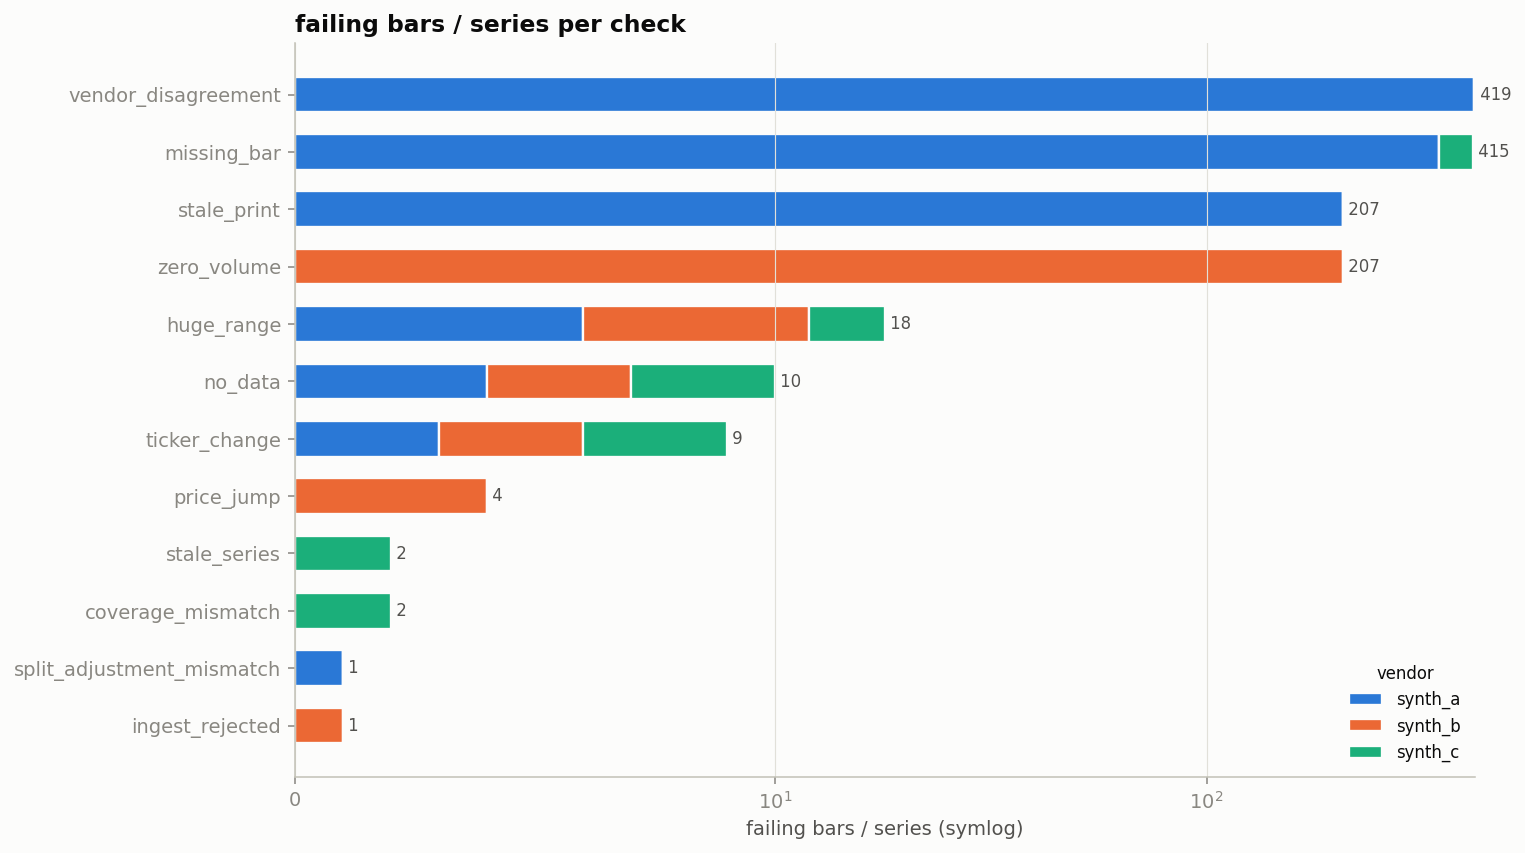
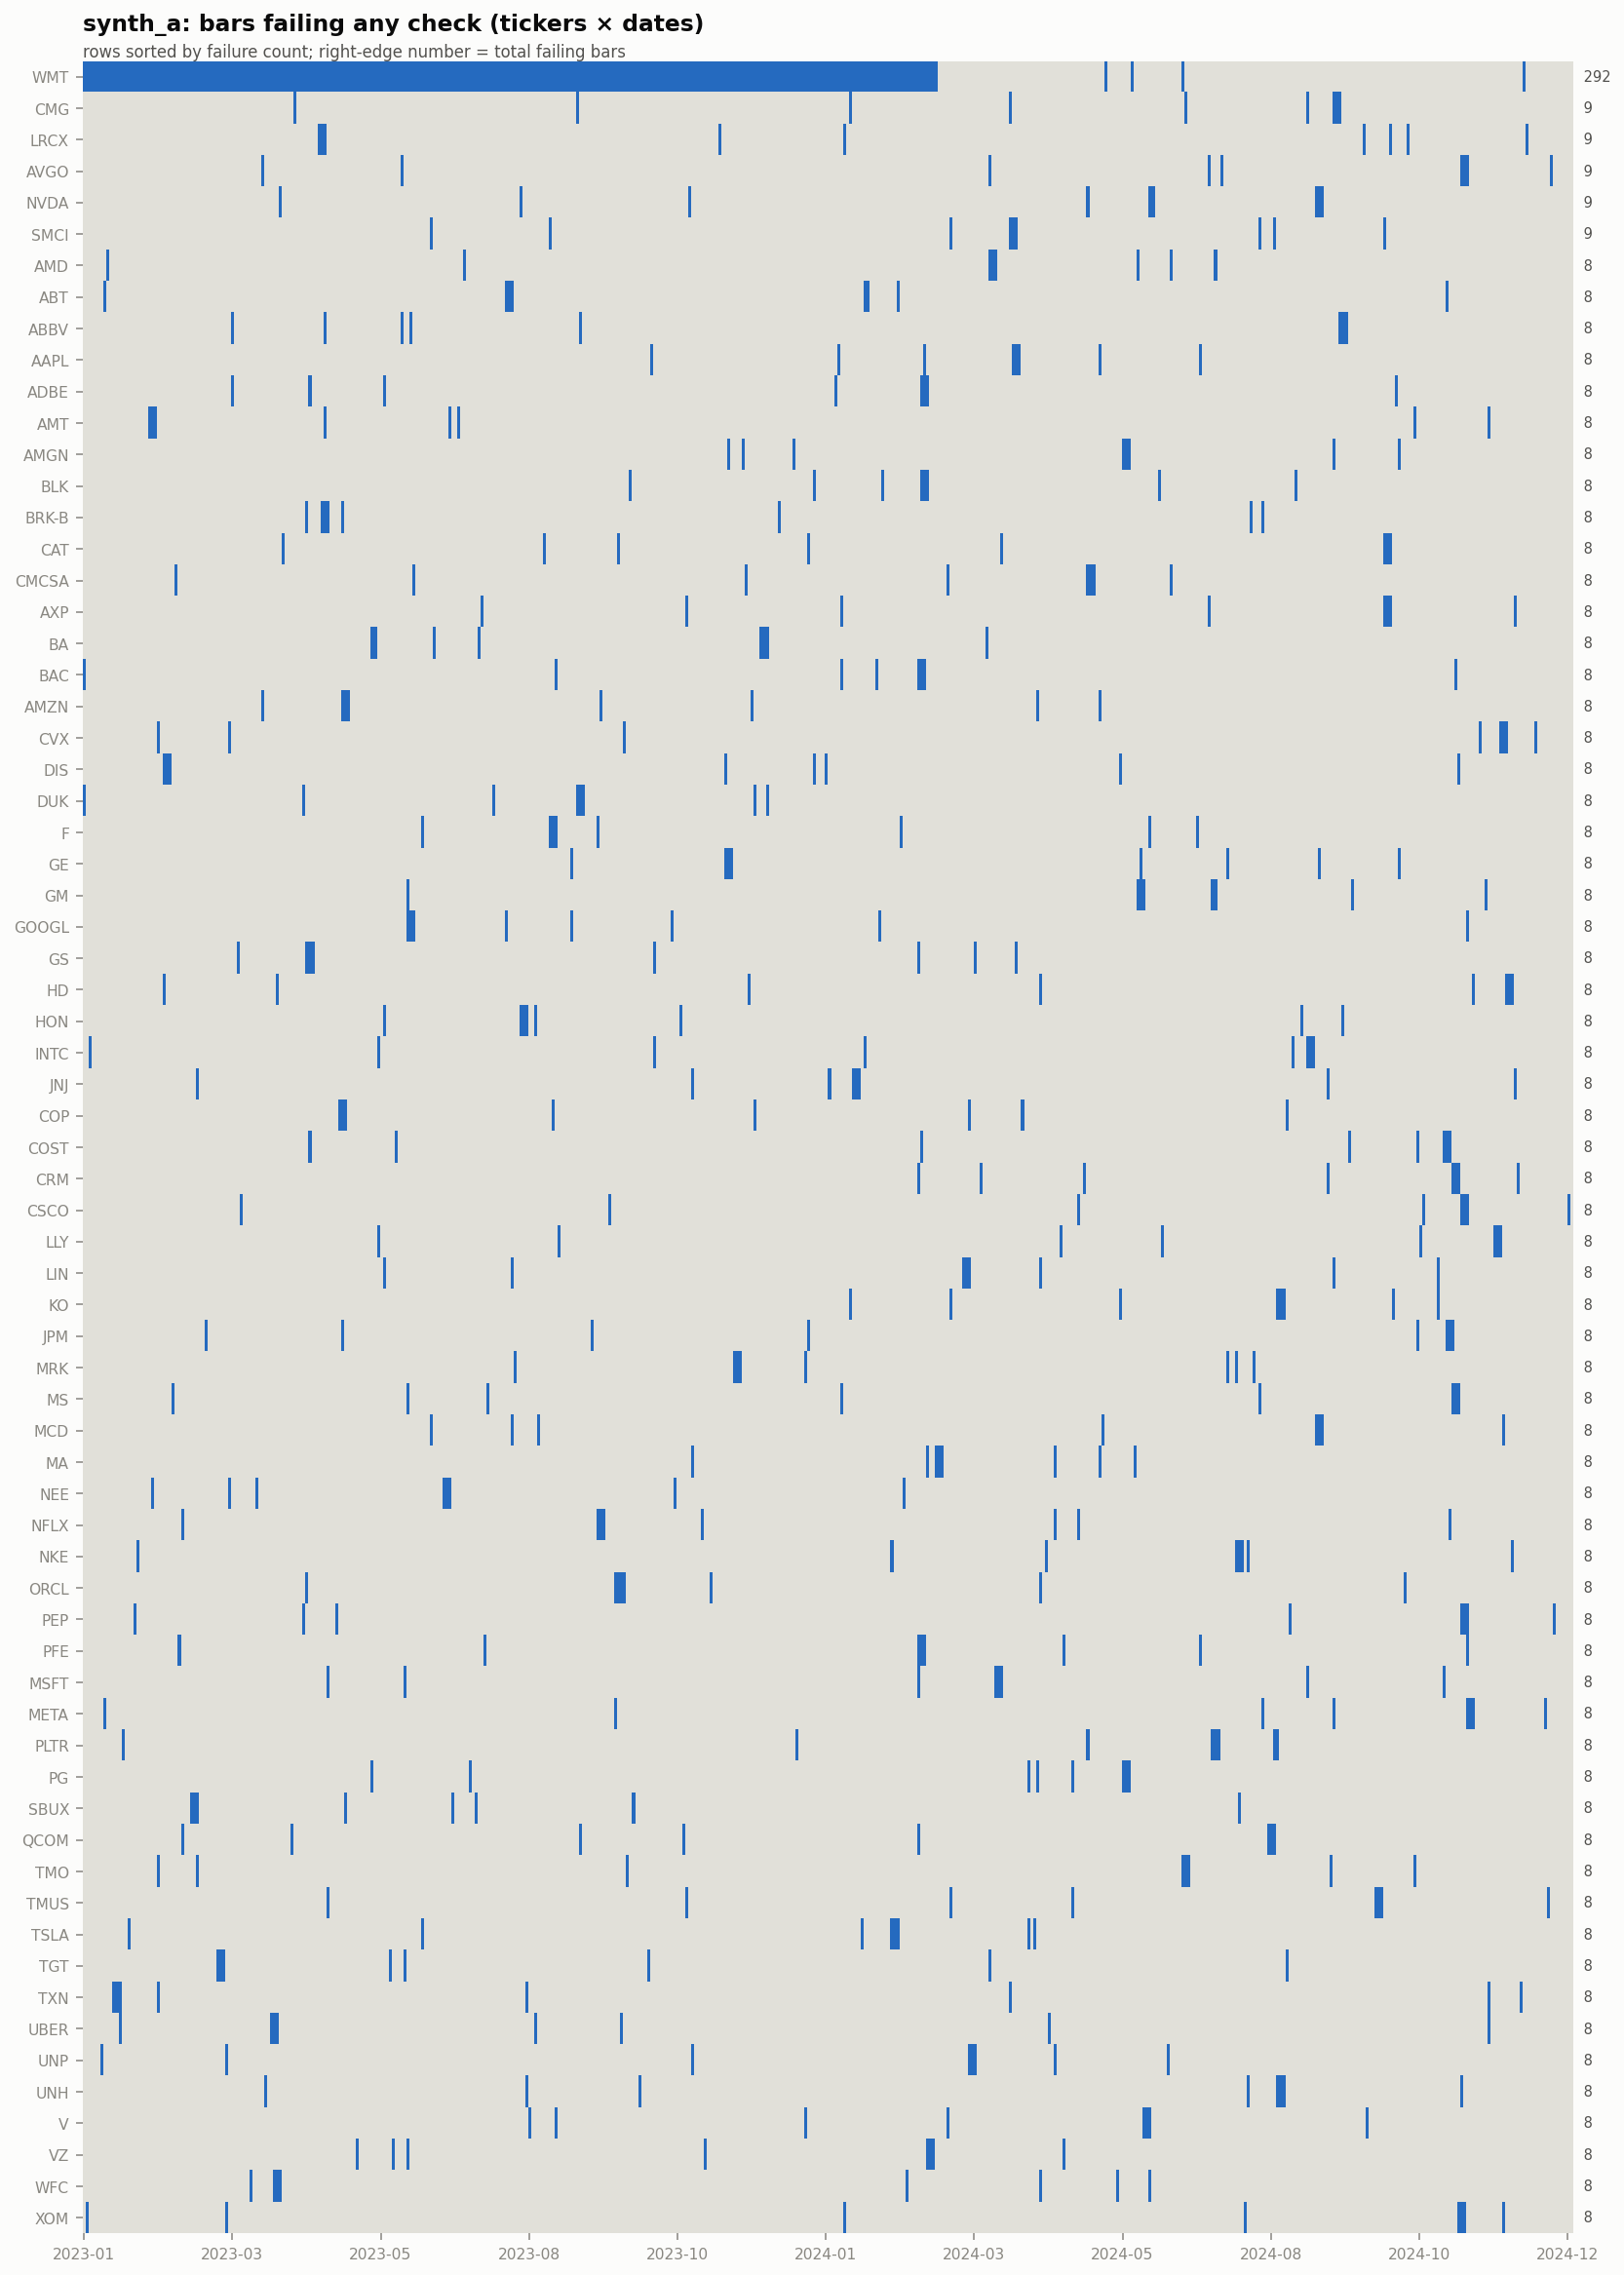
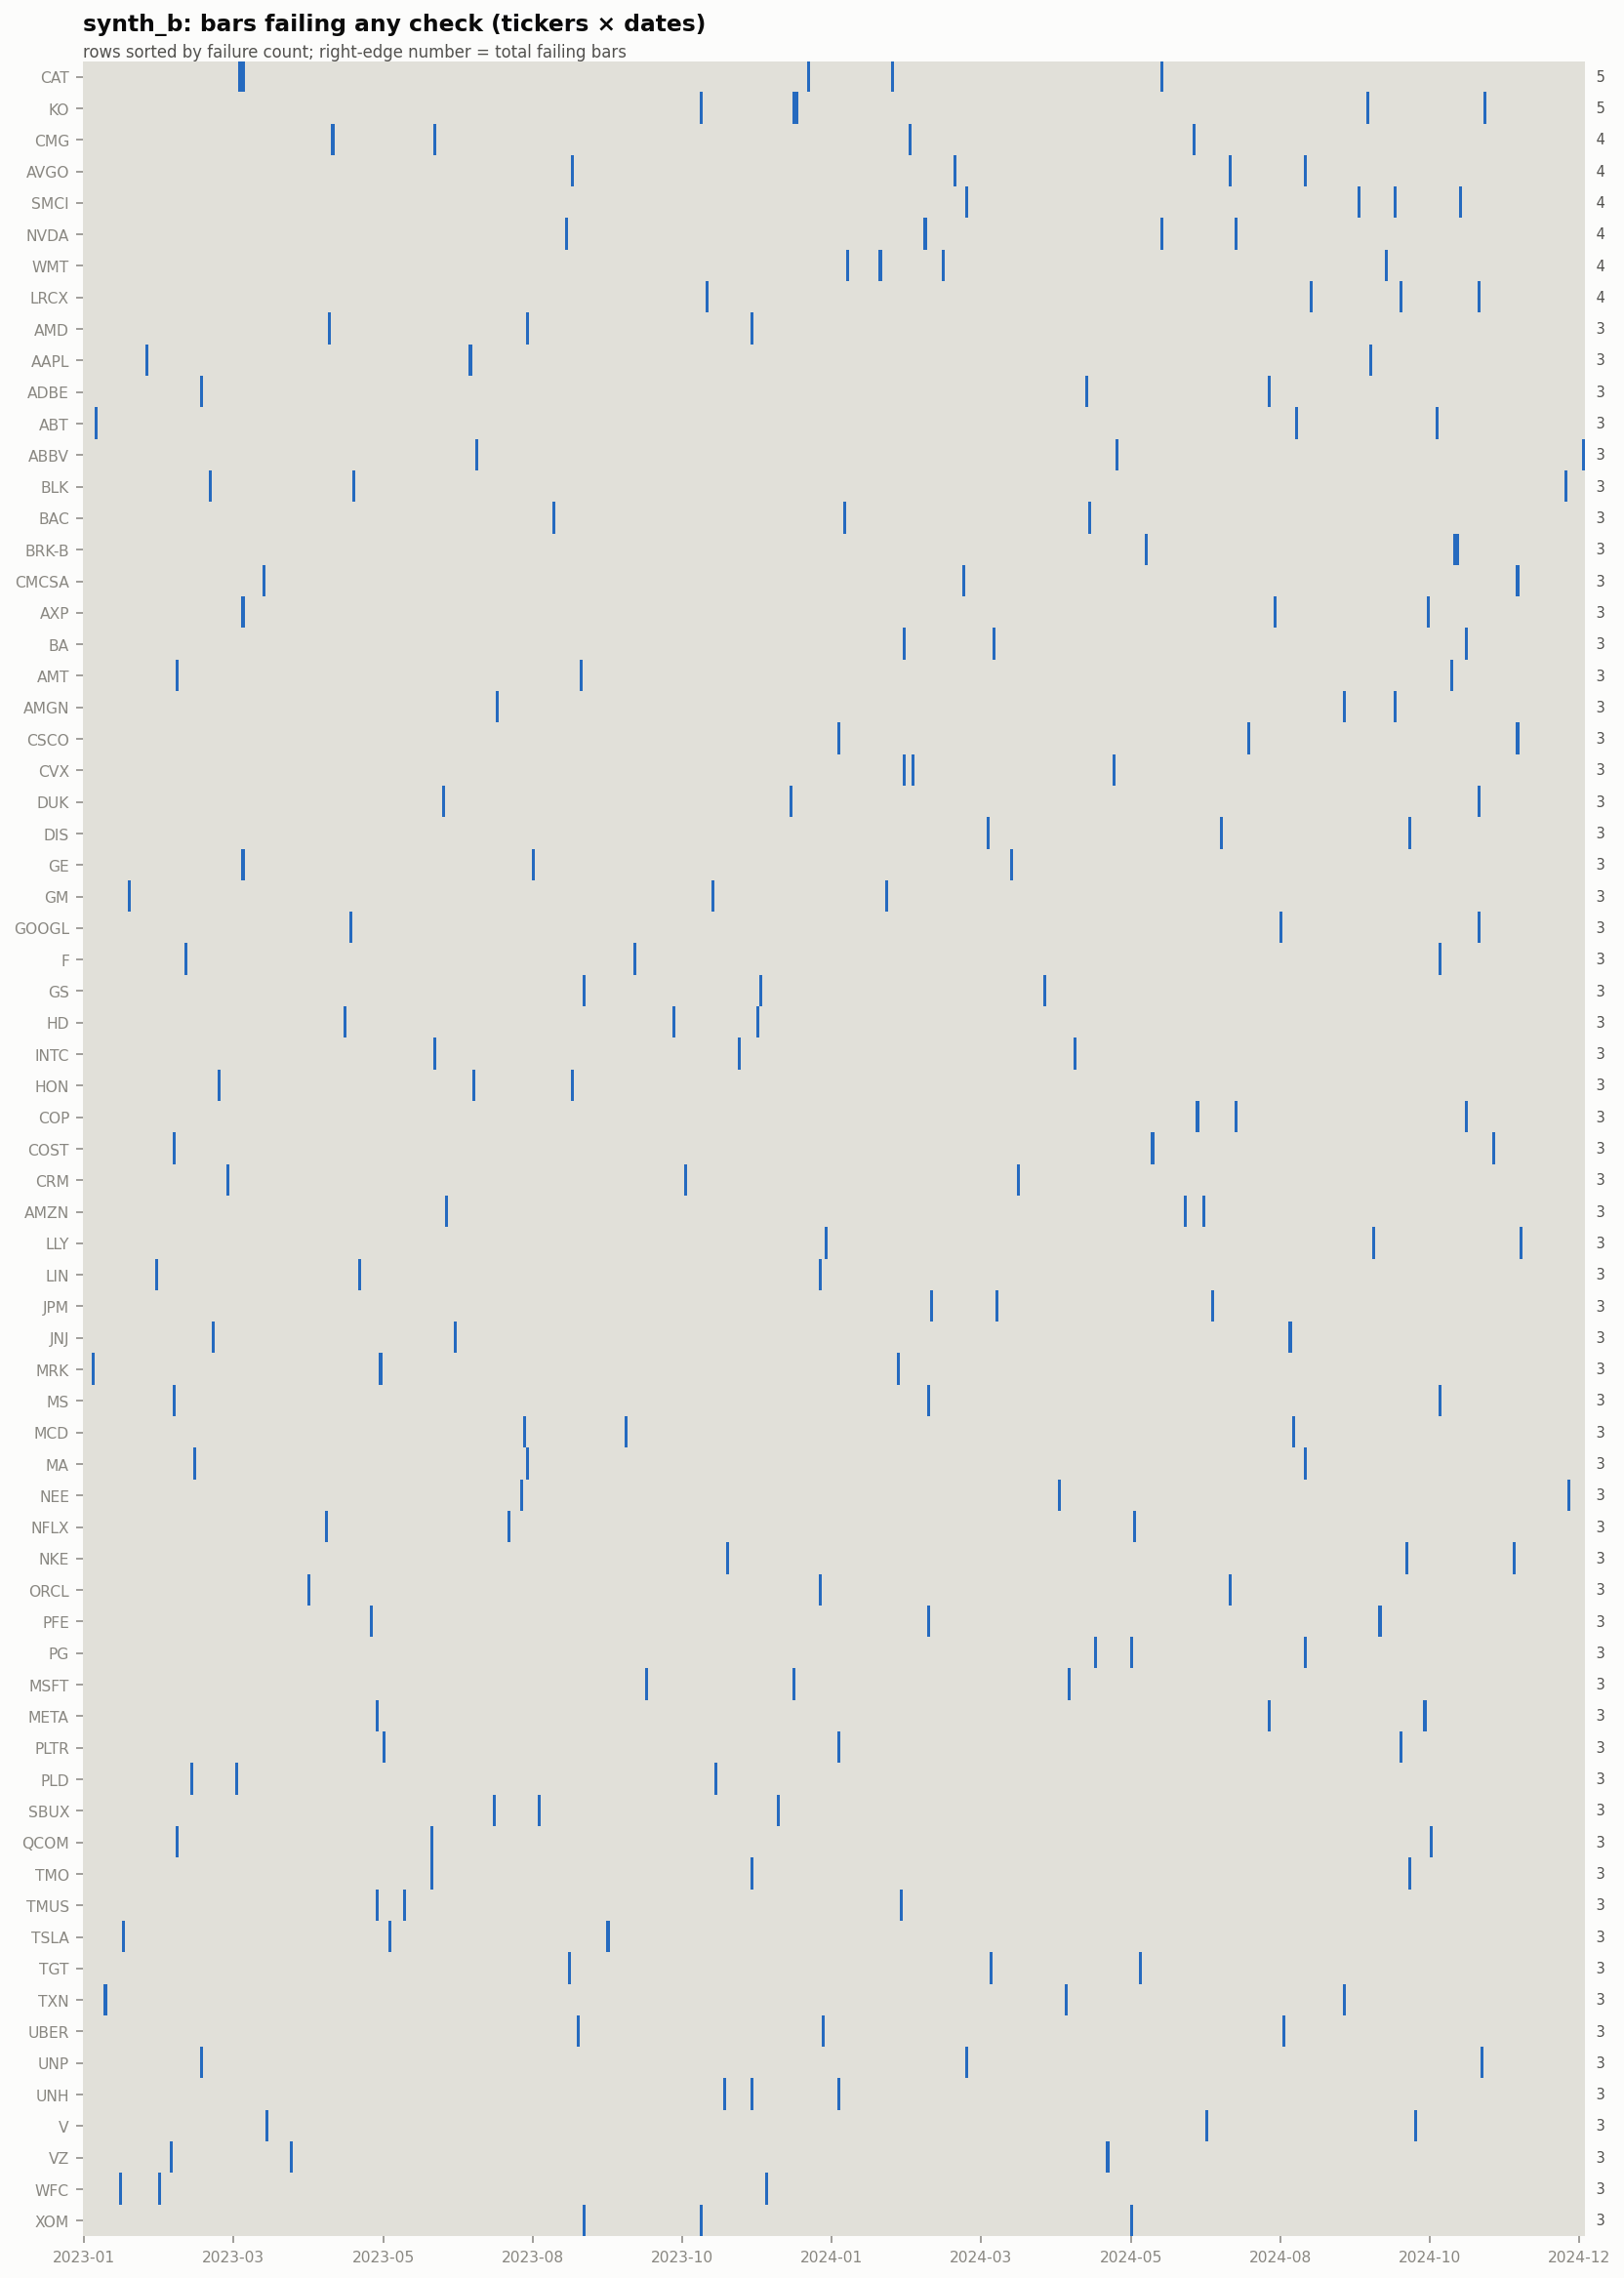
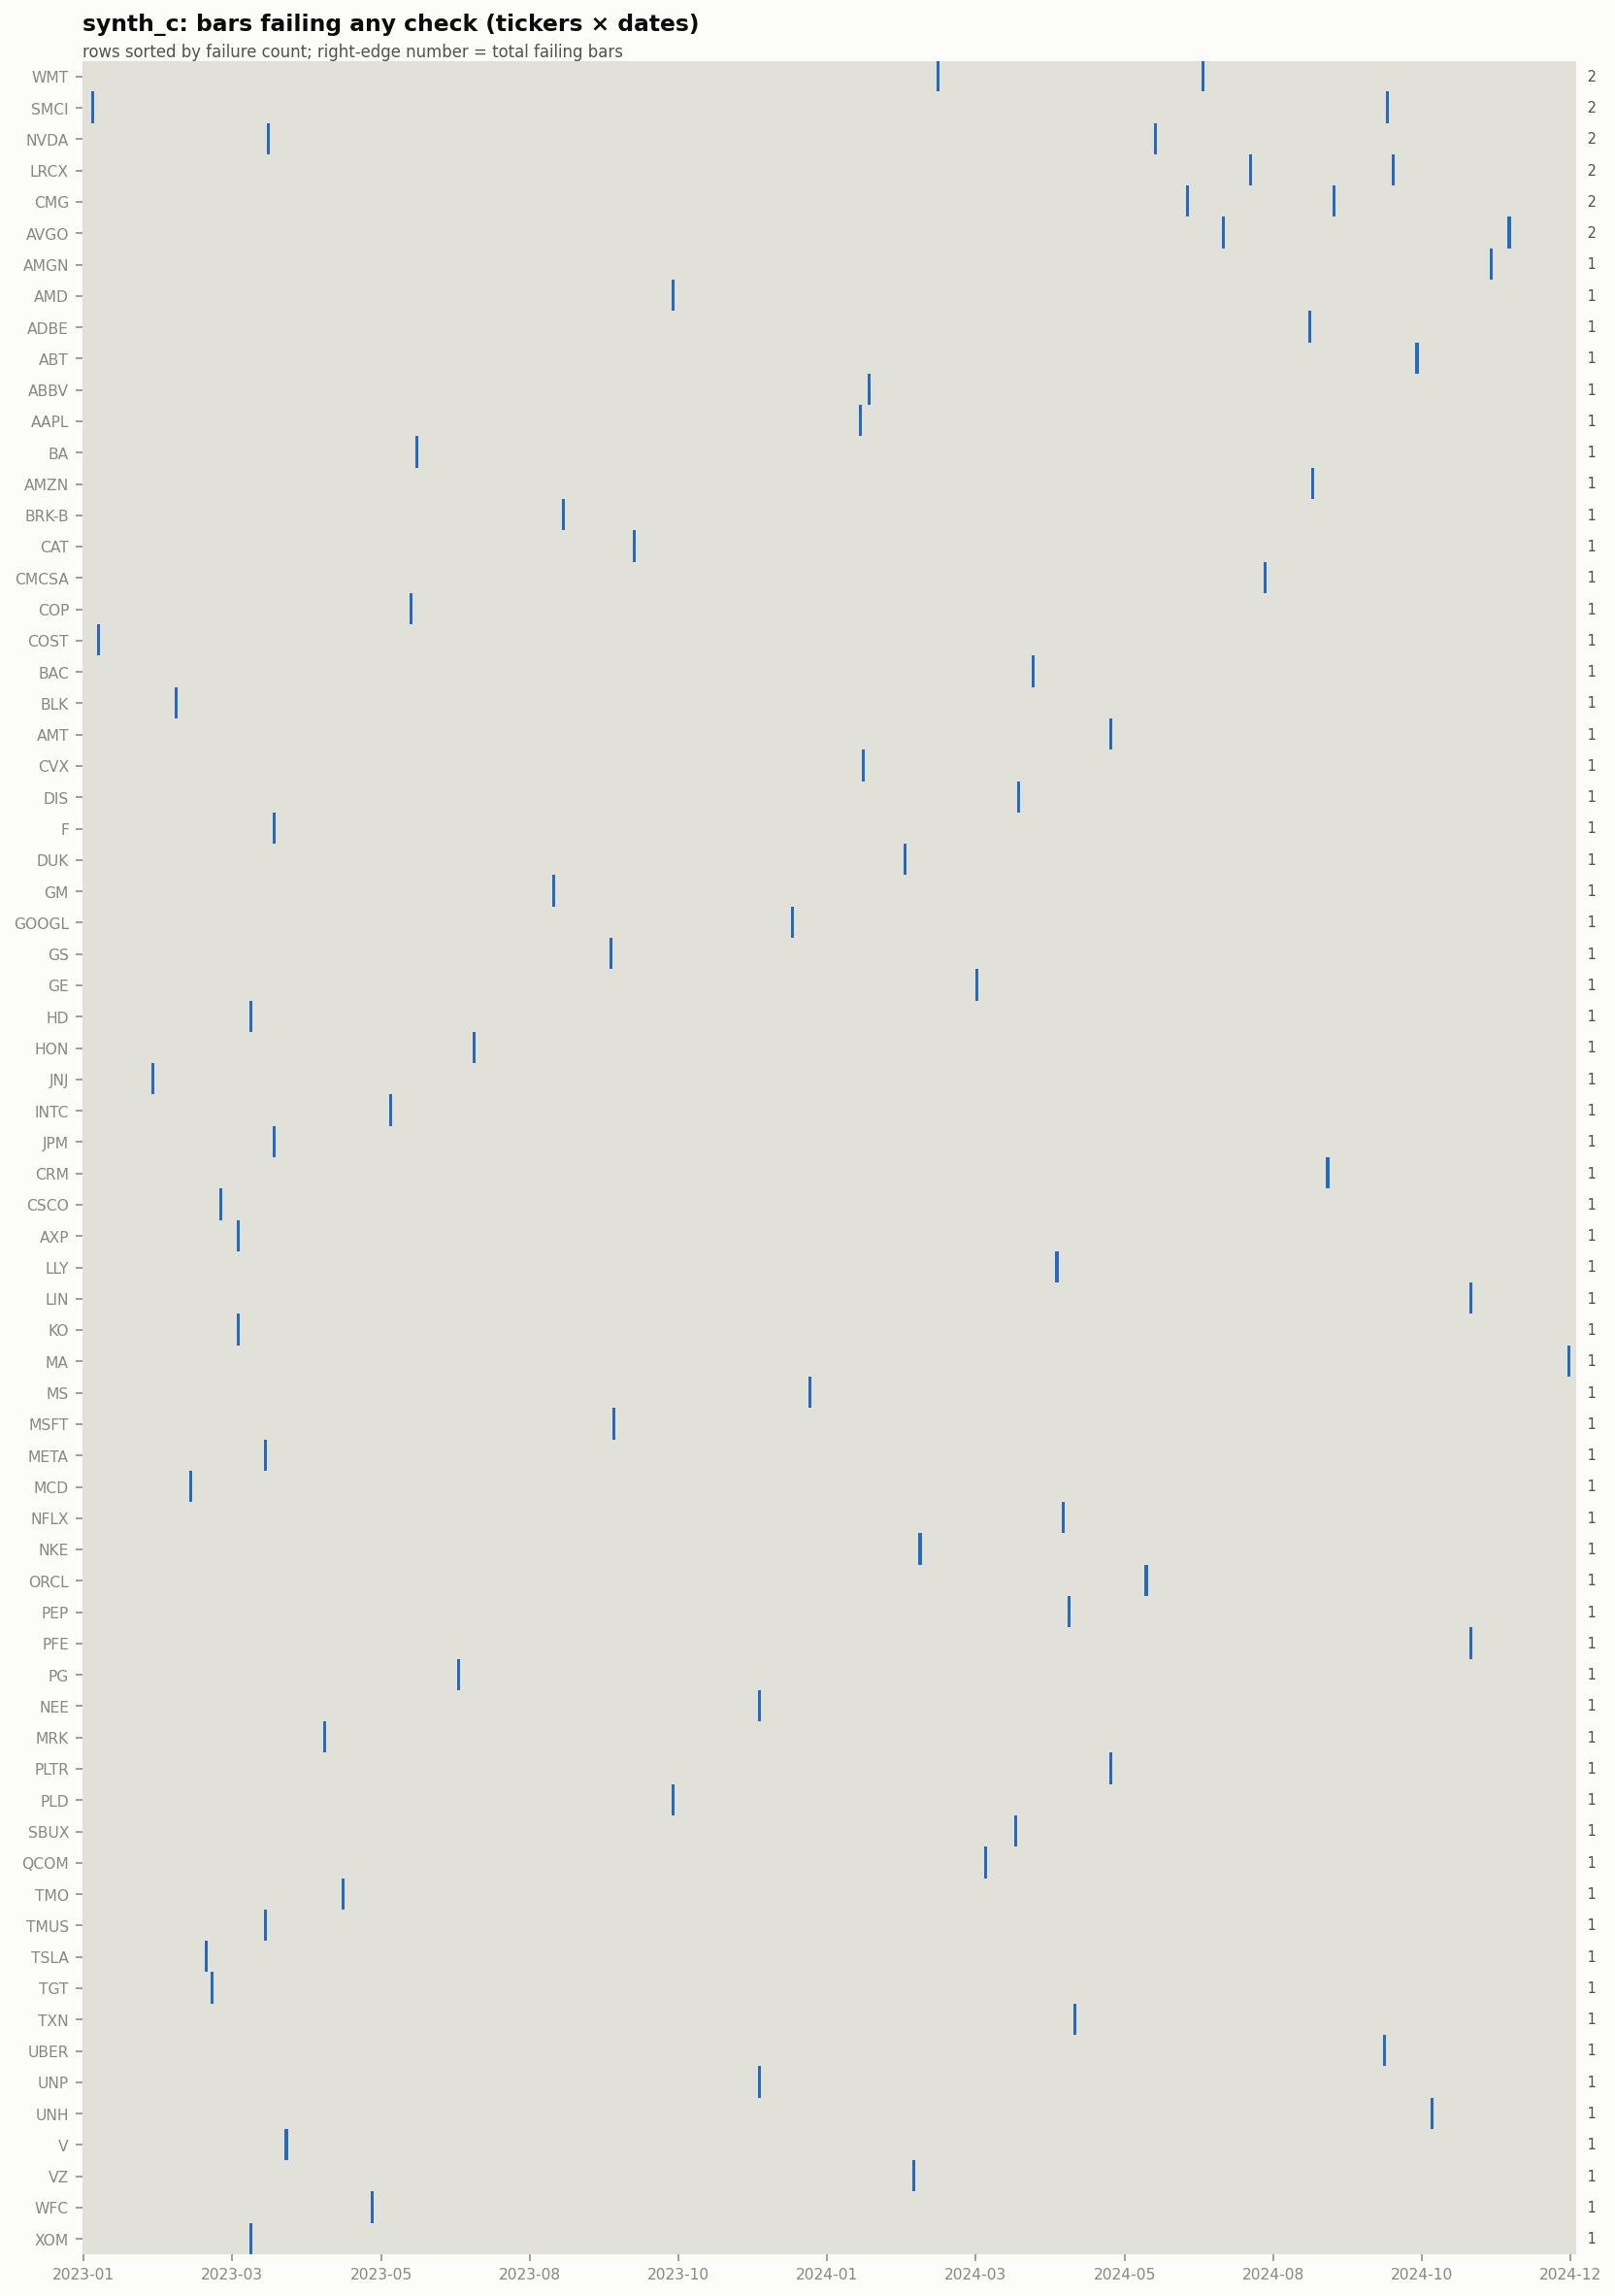

In [20]:
# preview inline (Colab renders the embedded figures)
HTML(open(res.report_paths["html"]).read())

In [21]:
# download from Colab
try:
    from google.colab import files
    files.download(str(res.report_paths["html"]))
except Exception:
    pass

## 12 · Documented discrepancies

Seven real findings with numbers live in [`docs/discrepancies.md`](docs/discrepancies.md). The short version:

1. **Yahoo's `Close` and `Volume` are split-adjusted** (NVDA 2024-06-07: tape $1,208.88, Yahoo 120.888).
2. **Polygon `adjusted=true` is split-only**; Yahoo/FMP are total-return — a staircase drift equal to the dividend yield.
3. **Yahoo restates historical dividends in post-split shares** (WMT $0.57 → $0.19) — feed that into a raw-basis engine and pre-split dividend factors are off by the split ratio.
4. **Adjusted prices are not point-in-time**: KO's adjusted close for 2024-06-07 is 62.51 / 61.62 / 59.56 depending on whether you anchor in Dec-2024, Aug-2025 or Sep-2026.
5. **`FB` now belongs to a ProShares ETF** listed June 2025 — a reused symbol; `late_start` + EDGAR catch it.
6. **Single-vendor `price_jump`/`stale_print` are screens, not error detectors** — all 35 live jump flags were real events; AMZN really closed at $125.98 three days running. Cross-vendor agreement is the error model.
7. **pandera rejects impossible bars at ingest** rather than loading 499 good bars and one `high < low`.

## 13 · Tests

In [22]:
!python -m pytest -q 2>&1 | tail -5

..............................                                           [100%]
30 passed in 3.38s


## 14 · Where to take it next

Point-in-time `as_of()` queries · more vendors (Tiingo, EODHD, Alpha Vantage) · CIK-keyed universe history · incremental refresh with restatement detection · DuckDB over the cache · per-ticker learned thresholds · nightly run + Slack alerts. See README §15.